In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from src.eda import dataset_overview, missing_values_report, check_duplicates, get_numerical_columns, skewness_report,plot_histograms,categorical_distribution,plot_categorical_distribution,correlation_heatmap,plot_boxplots,outlier_report
# Set plot style
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/data.csv")
df

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95657,TransactionId_89881,BatchId_96668,AccountId_4841,SubscriptionId_3829,CustomerId_3078,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-1000.0,1000,2019-02-13T09:54:09Z,2,0
95658,TransactionId_91597,BatchId_3503,AccountId_3439,SubscriptionId_2643,CustomerId_3874,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2019-02-13T09:54:25Z,2,0
95659,TransactionId_82501,BatchId_118602,AccountId_4841,SubscriptionId_3829,CustomerId_3874,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2019-02-13T09:54:35Z,2,0
95660,TransactionId_136354,BatchId_70924,AccountId_1346,SubscriptionId_652,CustomerId_1709,UGX,256,ProviderId_6,ProductId_19,tv,ChannelId_3,3000.0,3000,2019-02-13T10:01:10Z,2,0


#  Exploratory Data Analysis (EDA)


## Dataset Overview

In [3]:
dataset_overview(df)

DATASET OVERVIEW
Rows: 95662
Columns: 16

Data Types:
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 

## Missing Values Analysis

In [4]:
missing_values_report(df)

,Missing Count,Missing Percentage


## Duplicate Records

In [5]:
check_duplicates(df)

Duplicate Rows: 0


np.int64(0)

## Numerical Columns Extractor

In [6]:
numerical_cols = get_numerical_columns(df)

## Skewness Report

In [7]:
skewness_report(df)

Value              51.291086
Amount             51.098490
FraudResult        22.196295
PricingStrategy     1.659057
CountryCode         0.000000
dtype: float64

In [8]:
df["FraudResult"].value_counts(normalize=True)

FraudResult
0    0.997982
1    0.002018
Name: proportion, dtype: float64

In [9]:
df["PricingStrategy"].value_counts()

PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64

## Histograms

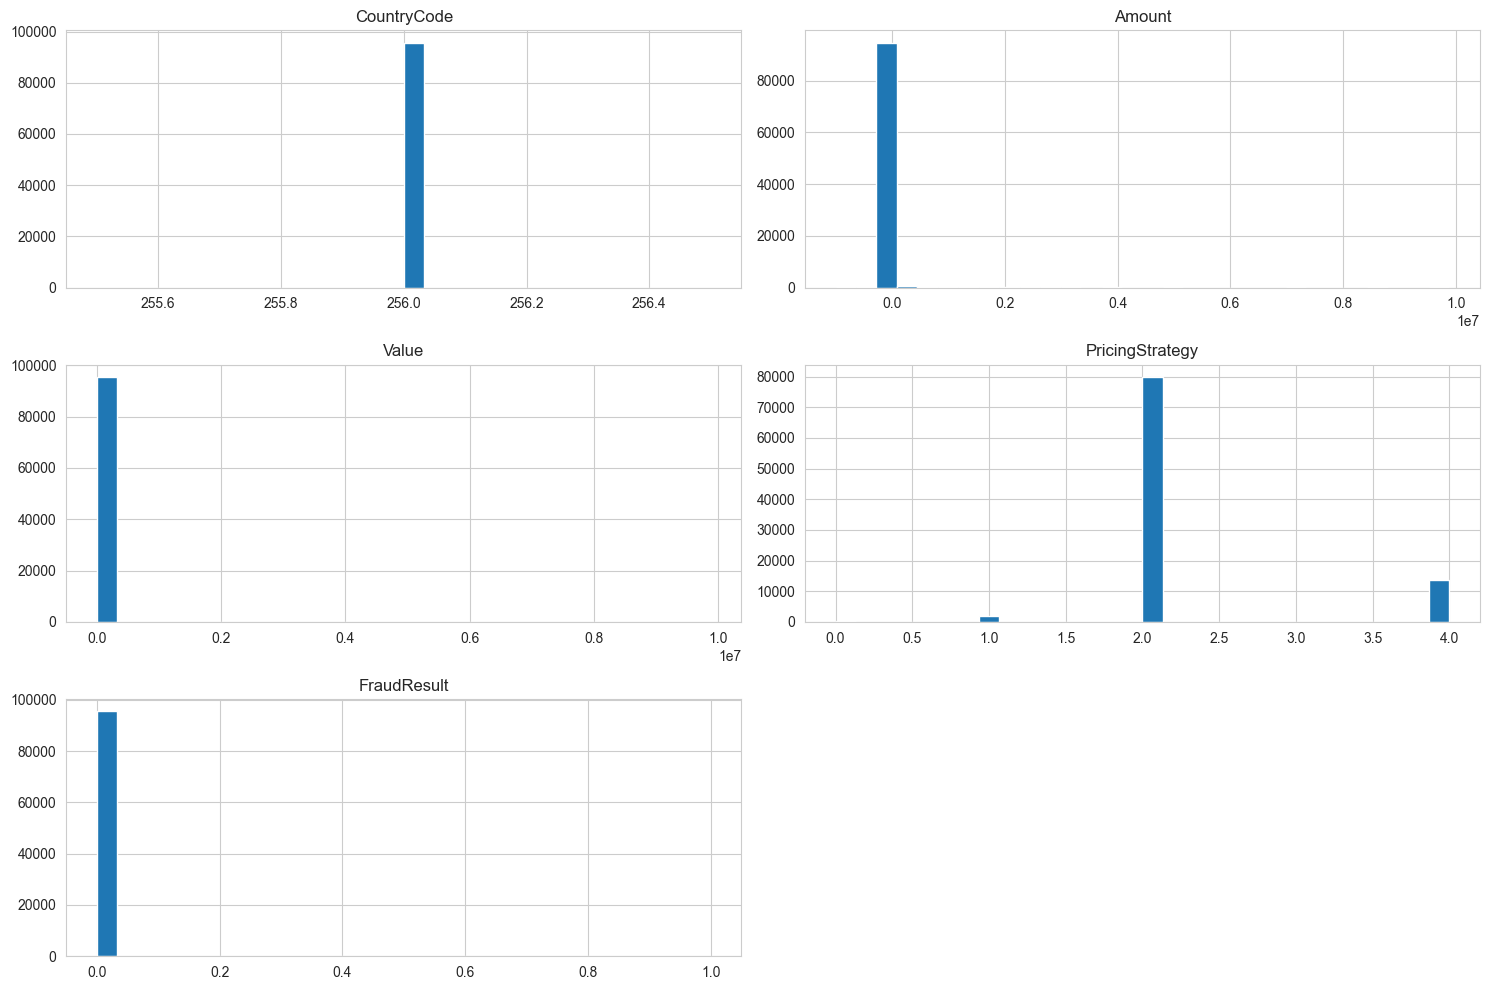

In [10]:
plot_histograms(df)

In [11]:
categorical_distribution(df)


TransactionId
TransactionId
TransactionId_76871     1
TransactionId_73770     1
TransactionId_26203     1
TransactionId_380       1
TransactionId_28195     1
                       ..
TransactionId_89881     1
TransactionId_91597     1
TransactionId_82501     1
TransactionId_136354    1
TransactionId_35670     1
Name: count, Length: 95662, dtype: int64

BatchId
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
                  ..
BatchId_96668      1
BatchId_3503       1
BatchId_118602     1
BatchId_70924      1
BatchId_29317      1
Name: count, Length: 94809, dtype: int64

AccountId
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
                  ...  
AccountId_3524        1
AccountId_2550        1
AccountId_417         1
AccountId_2476        1
AccountId_1685        1
Name: count, Length: 3633, dtype: int64

SubscriptionId
SubscriptionId

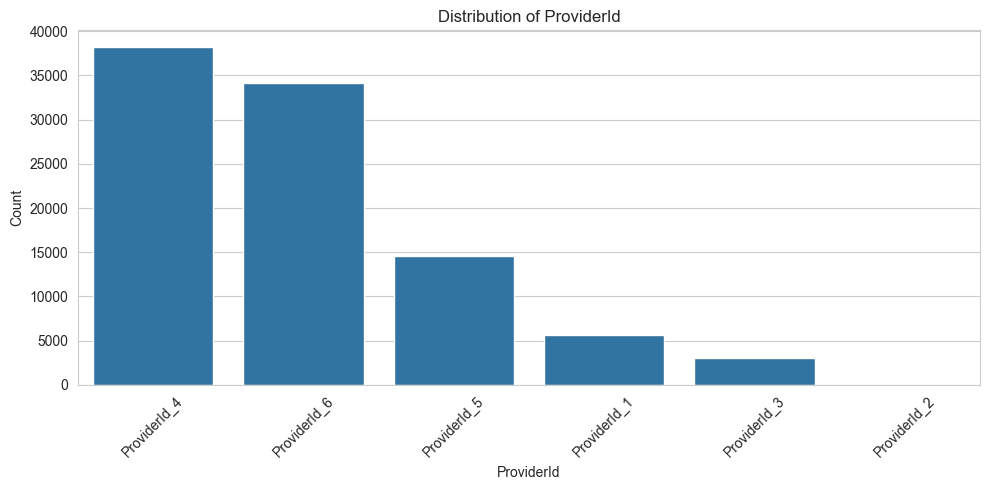

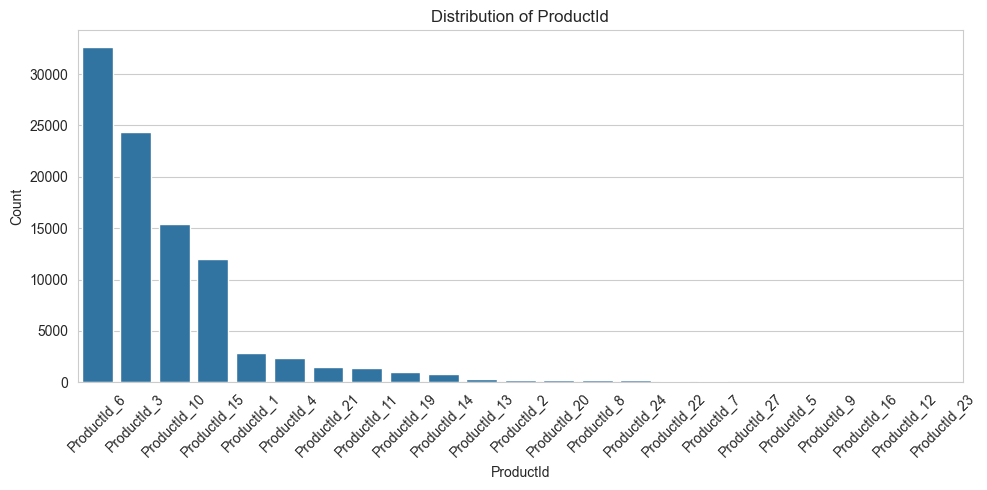

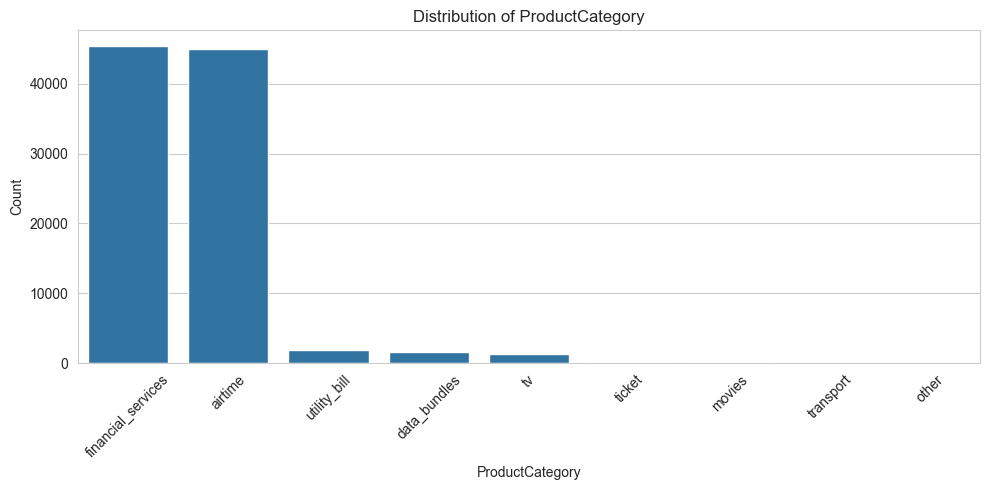

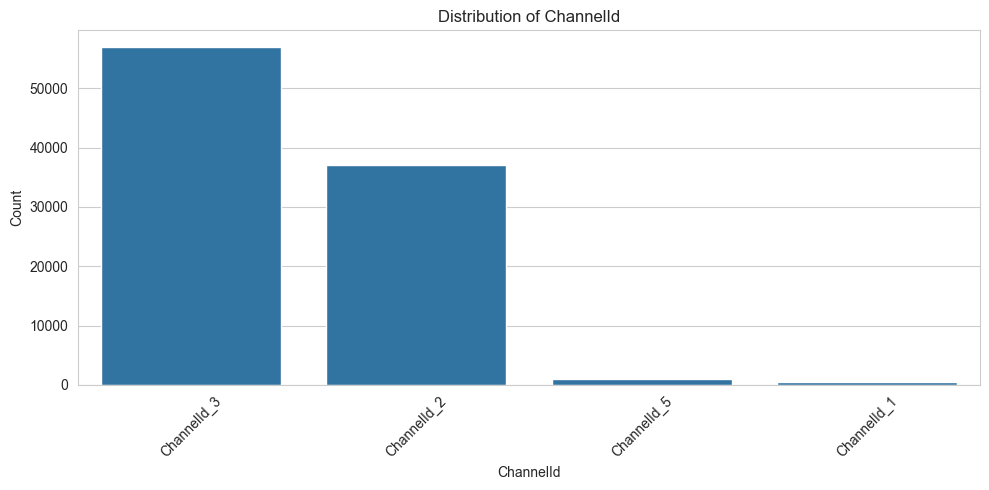

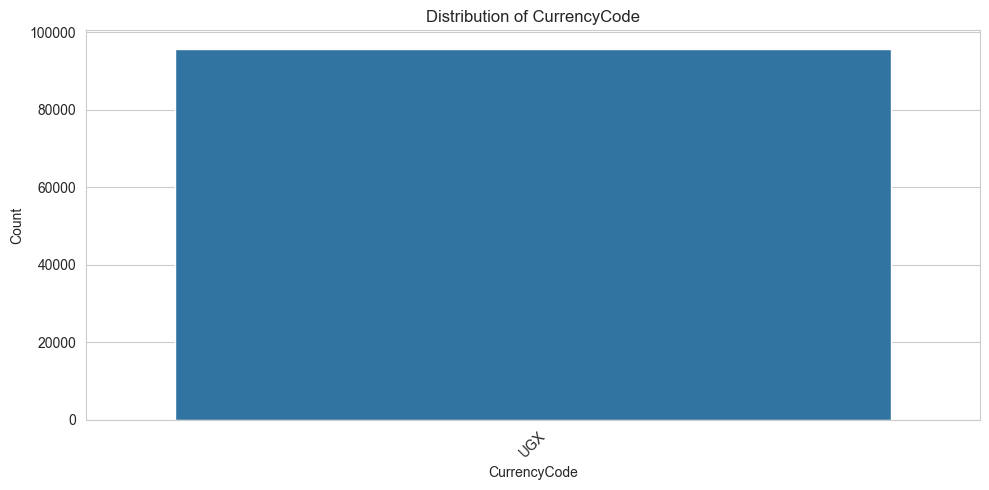

In [12]:
plot_categorical_distribution(df)

## Correlation

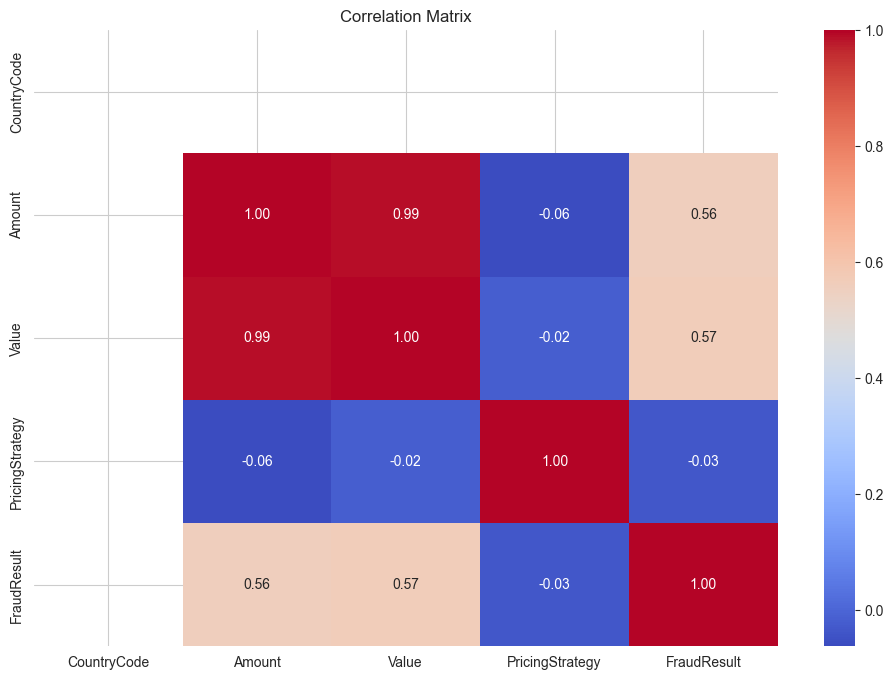

In [13]:
correlation_heatmap(df)

### Correlation Analysis

The correlation matrix was used to examine the linear relationships among the numerical variables in the dataset, namely **Amount**, **Value**, **PricingStrategy**, and **FraudResult**.

### Key Findings

- **Amount and Value** exhibited a very strong positive correlation (**0.99**). This is expected because `Value` represents the absolute transaction amount, indicating that the two variables contain largely redundant information.

- **Amount and FraudResult** showed a moderate positive correlation (**0.56**), suggesting that fraudulent transactions tend to involve larger transaction amounts.

- **Value and FraudResult** also demonstrated a moderate positive correlation (**0.57**), reinforcing the observation that higher-value transactions are more likely to be associated with fraudulent activity.

- **PricingStrategy** displayed very weak correlations with other numerical variables:
  - Amount: **-0.06**
  - Value: **-0.02**
  - FraudResult: **-0.03**

  These near-zero values indicate little direct linear relationship with transaction value or fraud occurrence.

- **CountryCode** was excluded from the correlation analysis because it contains only a single unique value, resulting in zero variance and providing no meaningful statistical information.

### Business Interpretation

The results suggest that transaction size, represented by **Amount** and **Value**, is an important indicator of fraud risk and may be a valuable predictor in credit risk modeling. In contrast, **PricingStrategy** appears to have limited predictive value when considered independently. Additionally, the strong correlation between **Amount** and **Value** indicates potential redundancy, which should be considered during feature selection and model development.

## Outlier Detection

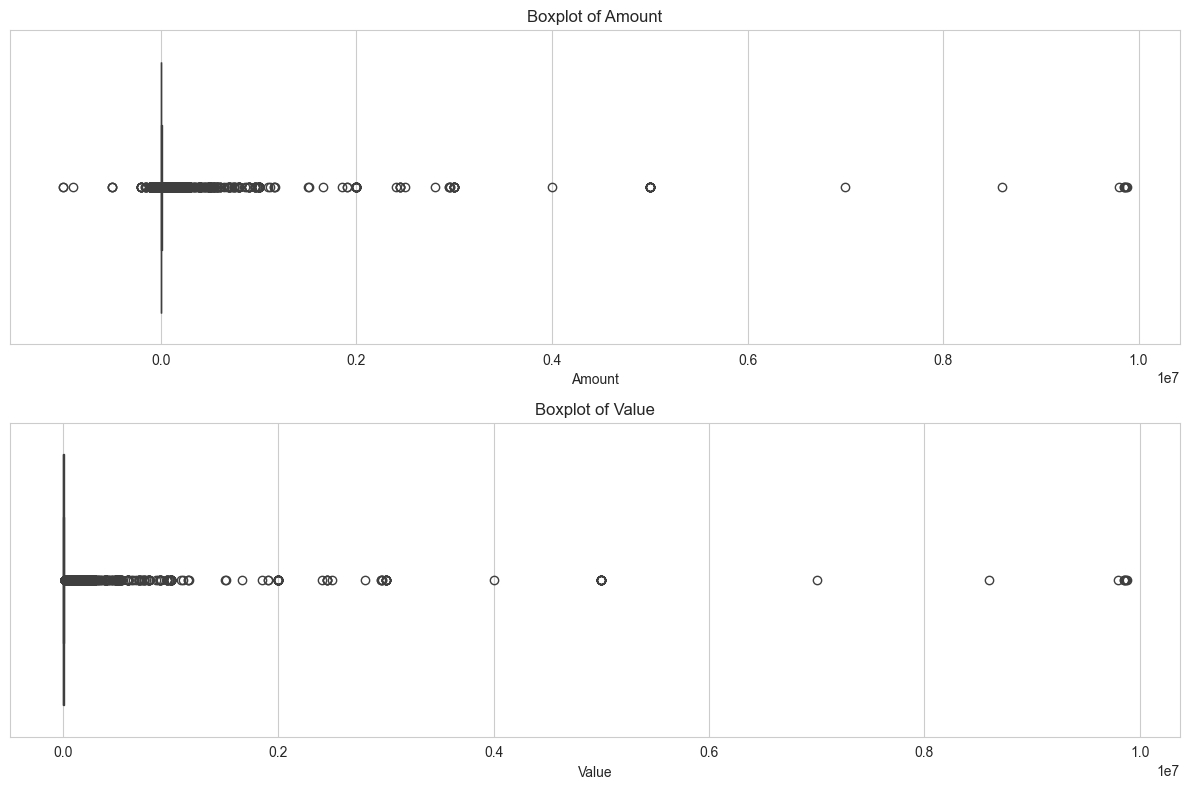

In [14]:
plot_boxplots(df)

In [15]:
outlier_report(df)

,Outlier Count,Outlier Percentage
Amount,24441.0,25.55
Value,9021.0,9.43


Outlier analysis revealed a substantial number of extreme values in the **Amount** and **Value** features, consistent with their highly right-skewed distributions. The boxplots showed that while most transactions are relatively small, a small proportion of transactions have exceptionally large values.

#### Business Interpretation

From a business perspective, these outliers likely represent high-value transactions, large merchant payments, or potentially fraudulent activities rather than data errors. Therefore, they should be retained for analysis, although transformation techniques such as logarithmic scaling may be applied to reduce skewness and improve model performance.

Variables such as **PricingStrategy** and **FraudResult** were excluded from interpretation since they represent categorical and binary data rather than continuous measurements.